PCA componete analises

In [30]:
!pip install ucimlrepo

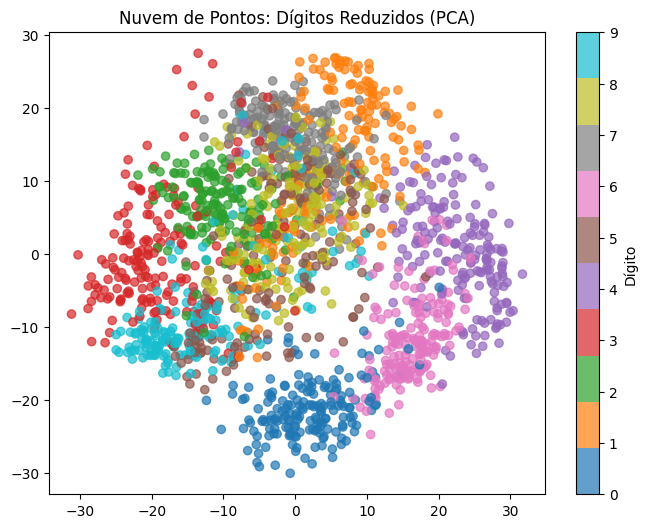

In [31]:
from sklearn import datasets
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Atividade 1: Carregar dígitos e aplicar PCA
digits = datasets.load_digits()
X = digits.data
y = digits.target

pca = PCA(n_components=2)
X_reduced = pca.fit_transform(X)

# Visualização da nuvem de pontos
plt.figure(figsize=(8, 6))
plt.scatter(X_reduced[:, 0], X_reduced[:, 1], c=y, cmap='tab10', alpha=0.7)
plt.colorbar(label='Dígito')
plt.title("Nuvem de Pontos: Dígitos Reduzidos (PCA)")
plt.show()

Código treino.txt

In [32]:
# Divisão dos dados (1/3 para teste)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.33, random_state=42, stratify=y
) # [cite: 240, 241, 307]

# Criação do modelo KNN com PCA embutido para consistência
k_neighbors = 15 # [cite: 242]
knn = KNeighborsClassifier(n_neighbors=k_neighbors)

# Treino do modelo com dados reduzidos
X_train_pca = pca.fit_transform(X_train)
knn.fit(X_train_pca, y_train) # [cite: 248]

print(f"Precisão do Modelo: {knn.score(pca.transform(X_test), y_test):.2f}") # [cite: 251]

Precisão do Modelo: 0.64


Código de teste.txt

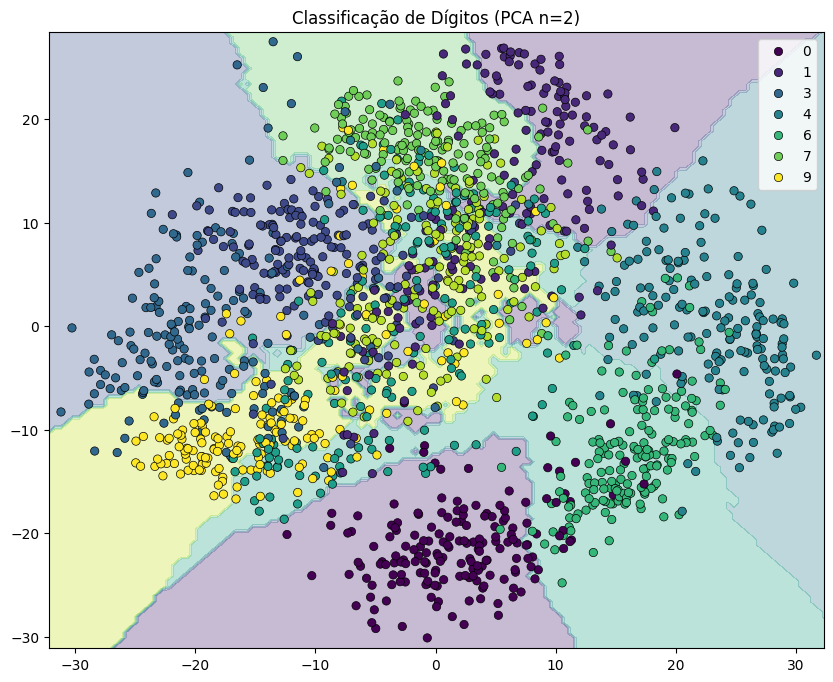

In [33]:
# Configuração da visualização (Cores)
cmap_bold = ["#000000", "#1f77b4", "#ff7f0e", "#2ca02c", "#d62728",
             "#9467bd", "#8c564b", "#e377c2", "#7f7f7f", "#bcbd22"]

# Criar malha para o fundo colorido (Fronteiras)
h = 0.5 # Tamanho do passo na malha [cite: 256]
x_min, x_max = X_reduced[:, 0].min() - 1, X_reduced[:, 0].max() + 1
y_min, y_max = X_reduced[:, 1].min() - 1, X_reduced[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h)) # [cite: 267]

# Predição na malha
Z = knn.predict(np.c_[xx.ravel(), yy.ravel()]) # [cite: 268]
Z = Z.reshape(xx.shape)

# Gráfico
plt.figure(figsize=(10, 8))
plt.contourf(xx, yy, Z, alpha=0.3) # Fronteiras de decisão [cite: 272]
sns.scatterplot(x=X_reduced[:, 0], y=X_reduced[:, 1], hue=y,
                palette="viridis", edgecolor="black") # Nuvem de pontos [cite: 81, 276]
plt.title("Classificação de Dígitos (PCA n=2)")
plt.show()

Código de previsão

In [34]:
# Exemplo de predição para um novo dado
# O dado deve ser transformado pelo PCA antes de entrar no KNN [cite: 45, 205]
novo_digito = X_test[0].reshape(1, -1)
novo_digito_pca = pca.transform(novo_digito)

predicao = knn.predict(novo_digito_pca)
print(f"O dígito previsto é: {predicao[0]}")
print(f"O dígito real era: {y_test[0]}")

O dígito previsto é: 6
O dígito real era: 6
